# ETP shipment lifecycle — model vs display

Single-load **material change ledger** for broker/DS questions: *what moved ETP50, Target 1/3, clocks, quantile refresh, or display workflow?*

**v1 cohort:** HC leadtime-isolated outliers (`leadtime_isolated_ind=1`, `primary_category=LeadtimeChange`).

Set `LOAD_ID` to override rank picker. Canonical example: rank **2** → load **9199475** (+55% avail→48hr, early_burst).


In [1]:
from IPython.display import Markdown, display

import polars as pl

from dqt import resolve_data_dir
from dqt.etp_lake import EtpLake
from dqt.etp_lifecycle import (
    COHORT_HC,
    explain_load,
    resolve_load_id,
    select_outlier_cohort,
)

# --- params ---
COHORT = COHORT_HC  # or "manual"
RANK = 2  # HC rank (9199475)
LOAD_ID = None  # set int to override rank
MIN_SHIFT_PCT = 0.10
TOP_N = 50
QUERY_MDE = True  # True hits Snowflake

data_dir = resolve_data_dir()
lake = EtpLake(data_dir)  # lake root is $DQT_DATA_DIR/etp_lake

hc_index = select_outlier_cohort(
    cohort=COHORT,
    min_shift_pct=MIN_SHIFT_PCT,
    top_n=TOP_N,
    data_dir=data_dir,
)
display(hc_index.select(
    "hc_rank", "loadnumber", "etp50_shift_pct", "path_archetype", "primary_category"
).head(10))

LOAD_ID = resolve_load_id(cohort=COHORT, rank=RANK, load_id=LOAD_ID, data_dir=data_dir)
print(f"Explaining load {LOAD_ID} (cohort={COHORT}, rank={RANK})")


hc_rank,loadnumber,etp50_shift_pct,path_archetype,primary_category
u32,i32,f64,str,str
1,9199475,0.53527,"""early_burst""","""LeadtimeChange"""
2,9119169,0.43117,"""late_cliff""","""LeadtimeChange"""
3,6425193,0.42674,"""late_cliff""","""LeadtimeChange"""
4,8851323,0.416672,"""late_cliff""","""LeadtimeChange"""
5,8218454,0.414007,"""early_burst""","""LeadtimeChange"""


Explaining load 9119169 (cohort=hc_leadtime_isolated, rank=2)


In [2]:
result = explain_load(lake, LOAD_ID, query_mde=QUERY_MDE, data_dir=data_dir)
payload = result["payload"]
ledger = result["ledger"]
summary = result["summary"]

display(Markdown(f"**Executive summary**\n\n{summary['one_liner']}"))
sh = summary["endpoint_shifts"]
print(
    f"  Model ETP50: ${sh.get('etp50_avail', 0):,.0f} avail → ${sh.get('etp50_48hr', 0):,.0f} @48hr"
    f"  ({sh.get('shift_pct', 0) * 100:+.1f}%)"
)
if summary.get("movement"):
    mv = summary["movement"]
    print(
        f"  Flags: leadtime_isolated={mv.get('leadtime_isolated_ind')}"
        f" clocks_moved={mv.get('clocks_moved_ind')}"
        f" index_clock_overlap={mv.get('index_clock_overlap_ind')}"
    )


2026-09-03 13:38:33.310 | INFO     | arriveds.snowflake.utils:query_sf:422 - <inline sql>: 0 rows x 5 cols in 3.78s (query_id=01c6d43e-0e15-8137-0000-94e58912ee1a)


**Executive summary**

Load 9119169: LeadtimeChange — Model ETP50 avail→48hr: $+294 (+43.2%) — drivers: model ETP +96 (+14.1%); model ETP +94 (+11.2%).

  Model ETP50: $681 avail → $976 @48hr  (+43.2%)


2026-09-03 13:38:37.646 | INFO     | arriveds.snowflake.utils:query_sf:422 - <inline sql>: 0 rows x 5 cols in 3.00s (query_id=01c6d43e-0e15-815c-0000-94e58913018e)
/Users/rarko/Git/Projects/etp/etp-explanations/src/dqt/etp_timeline.py:873: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


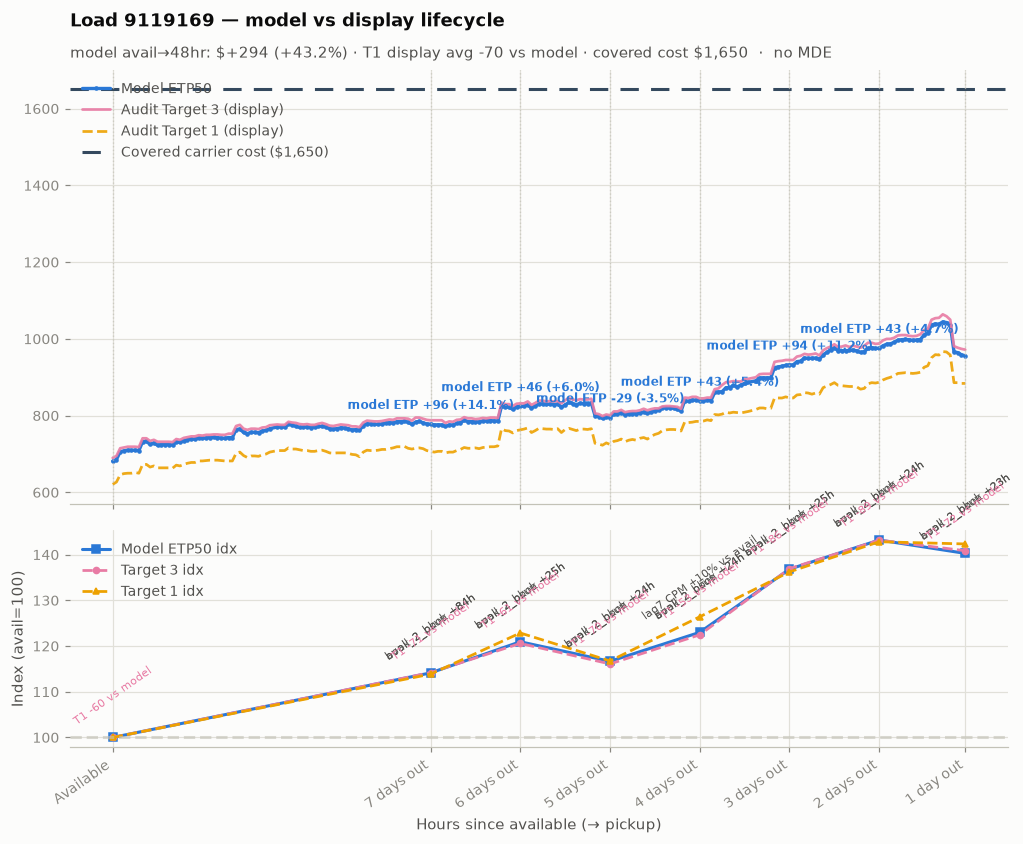

{'loadnumber': 9119169,
 'history': shape: (463, 10)
 ┌────────────┬────────────┬────────┬────────────┬───┬─────────┬────────────┬───────────┬───────────┐
 │ loadnumber ┆ snapshot_u ┆ source ┆ etp10      ┆ … ┆ target3 ┆ hours_befo ┆ hours_sin ┆ ship_mont │
 │ ---        ┆ tc         ┆ ---    ┆ ---        ┆   ┆ ---     ┆ re_pickup  ┆ ce_availa ┆ h         │
 │ i32        ┆ ---        ┆ str    ┆ f64        ┆   ┆ f64     ┆ ---        ┆ ble       ┆ ---       │
 │            ┆ datetime[n ┆        ┆            ┆   ┆         ┆ i32        ┆ ---       ┆ str       │
 │            ┆ s]         ┆        ┆            ┆   ┆         ┆            ┆ i32       ┆           │
 ╞════════════╪════════════╪════════╪════════════╪═══╪═════════╪════════════╪═══════════╪═══════════╡
 │ 9119169    ┆ 2026-06-26 ┆ model  ┆ 585.878017 ┆ … ┆ null    ┆ 253        ┆ 0         ┆ 2026-07   │
 │            ┆ 14:48:24.4 ┆        ┆            ┆   ┆         ┆            ┆           ┆           │
 │            ┆ 96004      ┆ 

In [3]:
# Timeline chart (model, T1, T3, realized cost)
lake.plot_etp_timeline(LOAD_ID, query_mde=QUERY_MDE)


In [4]:
# Material change ledger — core deliverable
pricing = ledger.filter(pl.col("is_pricing_driver"))
display_ledger = ledger.filter(~pl.col("is_pricing_driver"))

print(f"Pricing drivers: {pricing.height} rows | Display adjustments: {display_ledger.height} rows")
display(
    pricing.select(
        "hours_before_pickup",
        "metric",
        "delta_usd",
        "delta_other",
        "category",
        "confidence",
        "driver_text",
    ).head(30)
)


Pricing drivers: 38 rows | Display adjustments: 24 rows


hours_before_pickup,metric,delta_usd,delta_other,category,confidence,driver_text
i64,str,f64,f64,str,str,str
168,"""etp50""",96.276409,0.141292,"""LeadtimeChange""","""high""","""model ETP +96 (+14.1%)"""
168,"""book_2_pkup""",null,null,"""LeadtimeChange""","""high""","""book_2_pkup −84h"""
168,"""avail_2_book""",null,null,"""LeadtimeChange""","""high""","""avail_2_book +84h"""
149,"""etp50""",39.693875,39.183746,"""QuantileRefresh""","""high""","""quantile refresh: ETP +40, knn…"
149,"""book_2_pkup""",null,-0.983838,"""LeadtimeChange""","""high""","""book_2_pkup −1.0h with ETP +40"""
…,…,…,…,…,…,…
72,"""etp50""",94.186411,0.112374,"""LeadtimeChange""","""high""","""model ETP +94 (+11.2%)"""
72,"""book_2_pkup""",null,null,"""LeadtimeChange""","""high""","""book_2_pkup −25h"""
72,"""avail_2_book""",null,null,"""LeadtimeChange""","""high""","""avail_2_book +25h"""


In [5]:
# Checkpoint table
display(payload["checkpoints"])


loadnumber,mark_hrs,mark_label,etp50,hours_before_pickup,target1,target3,book_2_pkup,avail_2_book,etp50_idx,delta_etp50_prev,target1_idx,t1_gap,target3_idx,t3_gap
i64,i64,str,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
9119169,999,"""Available""",681.398435,999,621.0,690.0,235.193274,0.5,100.0,-96.276409,100.0,-60.398435,100.0,8.601565
9119169,168,"""7 days out""",777.674844,168,707.0,788.0,150.756196,84.437313,114.129238,-46.441756,113.848631,-70.674844,114.202899,10.325156
9119169,144,"""6 days out""",824.1166,144,763.0,832.0,126.159163,109.034346,120.944892,29.183799,122.866345,-61.1166,120.57971,7.8834
9119169,120,"""5 days out""",794.9328,120,725.0,801.0,102.545745,132.647764,116.661965,-43.217937,116.747182,-69.9328,116.086957,6.0672
9119169,96,"""4 days out""",838.150737,96,785.0,845.0,78.932005,156.261504,123.0045,-94.186411,126.409018,-53.150737,122.463768,6.849263
9119169,72,"""3 days out""",932.337148,72,846.0,945.0,54.079194,181.114316,136.827016,-43.492282,136.231884,-86.337148,136.956522,12.662852
9119169,48,"""2 days out""",975.82943,48,887.0,988.0,30.466869,204.72664,143.209814,19.91562,142.834138,-88.82943,143.188406,12.17057
9119169,24,"""1 day out""",955.91381,25,884.0,972.0,7.55681,227.636699,140.287057,null,142.351047,-71.91381,140.869565,16.08619


In [6]:
# Decomposition + top hourly steps
decomp = result.get("decompose") or {}
if decomp.get("by_day") is not None:
    display(decomp["by_day"].head(15))
else:
    print("decompose by_day unavailable")
display(payload["top_steps"])


decompose by_day unavailable


loadnumber,snapshot_utc_t0,snapshot_utc_t1,delta_etp50,delta_etp10,prebook_day,lead_day,delta_hours_before_pickup,delta_hours_since_available,delta_total_charges,delta_hard_ft_cnt,delta_hard_ft_cnt_improved,delta_hard_ft_cnt_reg,delta_charge_less_dat,delta_dat_rate,delta_mean_pred_mkt_rt,delta_fuel_cost,delta_fsc,delta_lag7_cpm_x_miles,delta_ra7_cpm_x_miles,delta_book_2_pkup,delta_book_2_pkup_days,delta_avail_2_book,delta_avail_2_book_days,delta_clhp_ma,delta_clhp_pred_line,delta_clhp_pred_tot_cost,delta_knn_50,delta_knn_avg_distance,delta_loaded_miles,delta_miles_feat,ship_month,is_hyperlocal,loaded_miles
i32,datetime[ns],datetime[ns],f64,f64,i64,i64,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i16,f64,str,bool,i16
9119169,2026-06-30 21:56:16.529460,2026-06-30 22:55:18.373775,39.693875,39.452321,4,6,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.3,-0.03,-11.918418,3.653989,-0.983838,0.0,0.983838,0.0,null,1.1369e-13,-6.3,39.183746,-0.004378,0,0.0,"""2026-07""",false,210
9119169,2026-07-03 22:01:03.885617,2026-07-03 23:00:05.626108,29.741579,33.693589,7,3,-1,1,0.0,0.0,0.0,0.0,-33.76,0.0,33.76,0.0,0.0,-77.631401,-9.550372,-0.983816,0.0,0.983816,0.0,null,-2.2737e-13,-2.2737e-13,31.586304,0.001089,0,0.0,"""2026-07""",false,210
9119169,2026-07-02 22:08:55.975665,2026-07-02 23:07:57.799841,27.566928,21.633237,6,4,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,125.247058,21.636972,-0.983849,0.0,0.983849,0.0,null,2.2737e-13,2.2737e-13,26.468231,-0.008814,0,0.0,"""2026-07""",false,210
9119169,2026-07-01 22:32:06.104046,2026-07-01 23:31:07.917208,-33.490644,-27.723343,5,5,-1,1,0.0,0.0,0.0,0.0,1.63,0.0,-1.63,0.0,0.0,-41.187702,9.296542,-0.983844,0.0,0.983844,0.0,null,-1.1369e-13,-2.2737e-13,-34.505554,-0.017613,0,0.0,"""2026-07""",false,210
9119169,2026-07-05 22:30:25.919562,2026-07-05 23:29:27.681667,-70.197003,-79.781415,9,1,-1,1,3.23,0.0,0.0,0.0,3.23,0.0,0.0,0.0,0.0,19.821014,-11.66022,-0.983829,0.0,0.983829,0.0,null,1.1369e-13,2.2737e-13,-67.655029,0.010963,0,0.0,"""2026-07""",false,210


In [7]:
# Attribution card (broker one-liner drivers)
for i, row in enumerate(summary["attribution_card"], start=1):
    print(f"{i}. [{row['category']}] {row['driver_text']}")


1. [LeadtimeChange] model ETP +96 (+14.1%)
2. [LeadtimeChange] model ETP +94 (+11.2%)
3. [QuantileRefresh] quantile refresh: ETP -70, knn_50 -68


In [8]:
# Display adjustments (segregated)
display(display_ledger.select("hours_before_pickup", "metric", "driver_text").head(20))


hours_before_pickup,metric,driver_text
i64,str,str
999,"""display""","""T1 -60 vs model"""
168,"""target3""","""target3 +98 vs prior checkpoin…"
168,"""target1""","""target1 +86 vs prior checkpoin…"
168,"""display""","""T1 -71 vs model"""
149,"""target1""","""Target 1 +45 (hourly audit sna…"
…,…,…
76,"""target1""","""Target 1 +27 (hourly audit sna…"
72,"""target3""","""target3 +100 vs prior checkpoi…"
72,"""target1""","""target1 +61 vs prior checkpoin…"


In [9]:
# Gallery mode — top N HC outliers (optional)
GALLERY = True
if GALLERY:
    for row in hc_index.head(5).iter_rows(named=True):
        ln = int(row["loadnumber"])
        ex = explain_load(lake, ln, data_dir=data_dir)
        print(ex["summary"]["one_liner"])
else:
    print("Set GALLERY=True to iterate top HC outliers")


Load 9199475: LeadtimeChange — Model ETP50 avail→48hr: $+336 (+54.8%) — drivers: model ETP +156 (+25.5%); quantile refresh: ETP +93, knn_50 +95.
Load 9119169: LeadtimeChange — Model ETP50 avail→48hr: $+294 (+43.2%) — drivers: model ETP +96 (+14.1%); model ETP +94 (+11.2%).
Load 6425193: LeadtimeChange — Model ETP50 avail→48hr: $+172 (+34.2%) — drivers: quantile refresh: ETP +131, knn_50 +132; model ETP +123 (+24.5%).
Load 8851323: LeadtimeChange — Model ETP50 avail→48hr: $+225 (+41.5%) — drivers: model ETP +115 (+18.6%); model ETP +99 (+14.8%).
Load 8218454: LeadtimeChange — Model ETP50 avail→48hr: $+248 (+41.4%) — drivers: model ETP +75 (+10.3%); quantile refresh: ETP +68, knn_50 +71.


## Lightning cost tracking

Ledger rows with `Lightning` in `driver_text` — CLHP endpoint, path checkpoint, and hourly moves.
Threshold defaults: **$50 abs OR 10% rel** (see `notebooks/etp-slider/lightning-cost-threshold.ipynb`).


In [10]:
lightning = result.get("lightning") or {}
print("Endpoint summary:", lightning.get("endpoint_summary"))
lt_rows = ledger.filter(pl.col("driver_text").str.contains("Lightning"))
print(f"Lightning ledger rows: {lt_rows.height}")
display(lt_rows.select(
    "hours_before_pickup", "metric", "delta_usd", "delta_other", "category", "driver_text"
).head(20))


Endpoint summary: {'clhp_pred_tot_cost_delta': -6.300000000000182, 'clhp_pred_tot_cost_avail': 1118.498245463381, 'clhp_pred_tot_cost_rel_pct': 0.005632552420670239, 'clhp_pred_line_delta': -1.1368683772161603e-13, 'clhp_pred_line_avail': 979.8982454633809, 'clhp_pred_line_rel_pct': 1.1601902365674206e-16, 'clhp_change_ind': 0}
Lightning ledger rows: 0


hours_before_pickup,metric,delta_usd,delta_other,category,driver_text
i64,str,f64,f64,str,str
